In [1]:
import os
import time
import math
import json
import random
import pandas as pd
import numpy as np
import scipy as sp
import pylab as plt
import seaborn as sns
from matplotlib.colors import LogNorm
from matplotlib.lines import Line2D

In [2]:
%load_ext autoreload
%autoreload 2
import src.count_utils as utils

In [3]:
import jupyter_black

jupyter_black.load()

In [4]:
plt.style.use("../src/mpl_style.txt")

### Excess word list with frequency cutoff (non-lemmatized)
To determine the optimal rare word list that yields the best LLM use estimate,
we try different frequency cutoffs. The base list consists of all excess style 
words from the 2024 pubmed data. For each cutoff value, only words with frequency 
lower than the cutoff (average 2024) are considered into the list 
of rare words. 

In this version, word lemmata are being ignored and each 
version of a word is treated as a separate entity, e.g "delves" != "delve"
This could be a meaningful difference, because LLMs might have preferences
for certain versions of a word, but not others (how does tokenization work 
for ChatGPT? is the base token for "delve", "delves", "delving" the same?
is this relevant? despite having the same base tokens, different variants
occurr in different semantic and syntactic contexts, so to differentiate
between variants could still be informative, despite being based on the 
same token)

Procedure:
- get all 2024 excess words from the previous paper 
- compute the non-lemmatized average 2024 frequencies for the excess words 
(if they are present in the section vocabulary)
- filter list to only include words with average 2024/2025 frequency below cutoff
- group counts for all words in list
- use new counts to compute frequency, diffs, ratios and projection 
- repeat for every cutoff and section

Open questions:
- should there be a lower bound for frequencies (i.e. 1e-4) as there was in the 
paper? The excess words were determined with a lower bound, so they already 
exclude artefacts

In [5]:
VERSION = "research-article_aimrd_f_run2"
RESULTS_PATH = "../data/results/baseline_2025-06-26/" + VERSION
secs = next(os.walk(RESULTS_PATH))[1]
# values are either "" or a section name, if not "", only use frequs of the given
# section to compute excess word lists to be used for all sections
vocab_version = ""

In [6]:
years = np.arange(2000, 2026)
months = np.arange(1, 13)
with open(os.path.join(RESULTS_PATH, "filters.json")) as f:
    filters = json.load(f)
dates = pd.to_datetime(filters["all_dates"])

In [7]:
excess_words = utils.excess_style_words_2024
len(excess_words)

379

In [8]:
cutoffs = [0.0002, 0.0005, 0.001, 0.002, 0.005, 0.01, 0.02, 0.05, 0.1, 0.2, 0.5, 1.0]
excess_words_cutoff = {}
cutoff_counts = np.zeros((len(secs), len(cutoffs)), dtype=int)

for i, sec in enumerate(secs):
    if not vocab_version == "":
        if not sec == vocab_version:
            continue

    excess_words_cutoff[sec] = {}

    X = sp.sparse.load_npz(os.path.join(RESULTS_PATH, sec, f"count_{sec}.pkl.npz"))
    print(X.shape)
    words = np.load(
        os.path.join(RESULTS_PATH, sec, f"words_{sec}.pkl.npy"), allow_pickle=True
    )

    ind_words = np.isin(words, excess_words)
    ind = dates.year == 2024

    counts = np.array(np.sum(X[ind, :][:, ind_words], axis=0)).ravel()
    totals = np.sum(ind)

    freqs_2024 = (counts + 1) / (totals + 1)

    for j, cutoff in enumerate(cutoffs):

        ind_excess = freqs_2024 < cutoff

        cutoff_counts[i, j] = np.sum(ind_excess)
        excess_words_cutoff[sec][cutoff] = words[ind_words][ind_excess]

pd.DataFrame(cutoff_counts, columns=cutoffs, index=secs)

(1342509, 1804886)
(1342509, 1097331)
(1342509, 793718)
(1342509, 833198)
(1342509, 678177)
(1342509, 267584)


,0.0002,0.0005,0.0010,0.0020,0.0050,0.0100,0.0200,0.0500,0.1000,0.2000,0.5000,1.0000
full,0,0,0,12,53,103,154,211,251,294,342,379
methods,30,74,120,162,212,240,276,325,342,355,372,379
discussion,0,2,27,54,120,170,204,254,297,333,365,379
results,10,34,69,111,172,216,245,287,327,346,372,379
introduction,0,11,40,83,142,193,236,290,323,346,375,379
abstract,25,65,121,164,222,253,294,332,355,370,378,379


In [9]:
excess_words_cutoff.keys()

dict_keys(['full', 'methods', 'discussion', 'results', 'introduction', 'abstract'])

In [10]:
freqs_dfs = {}

for sec in secs:
    if vocab_version == "":
        freqs_dfs[sec] = utils.get_cutoff_frequency(
            RESULTS_PATH,
            sec,
            excess_words_cutoff[sec],
            lemmatized="_non-lemmatized",
        )
    else:
        freqs_dfs[sec] = utils.get_cutoff_frequency(
            RESULTS_PATH,
            sec,
            excess_words_cutoff[vocab_version],
            lemmatized=f"_non-lemmatized_{vocab_version}_only",
        )

loading cutoff freqs
loading cutoff freqs
loading cutoff freqs
loading cutoff freqs
loading cutoff freqs
loading cutoff freqs


In [11]:
# standard error for binomial dist and subsequent fraction
def se(p: float, q: float, n: int):
    if p >= 1.0:
        p = 0.9999999999999999
    if q == 1.0:
        q = 0.9999999999999999
    var = (p * (1 - p) * (q - 1) ** 2) / ((1 - p) ** 4 * n) + (q * (1 - q)) / (
        (1 - p) ** 2 * n
    )
    if var <= 0:
        print(f"p: {p}, q: {q}, n: {n}")
    return math.sqrt(var)

In [12]:
for sec in secs:
    p = freqs_dfs[sec]["projection"]
    q = freqs_dfs[sec]["frequency"]
    n = [totals] * len(p)
    freqs_dfs[sec]["se"] = list(map(se, p, q, n))

In [13]:
# filter out cutoffs with too high base frequency
freqs_dfs_filtered = {}
for sec in secs:
    remove = freqs_dfs[sec][freqs_dfs[sec]["projection"] >= 0.99]["cutoff"].unique()
    freqs_dfs_filtered[sec] = freqs_dfs[sec][
        freqs_dfs[sec]["cutoff"].apply(lambda x: x not in remove)
    ].copy()

In [14]:
freqs_dfs["introduction"]

,cutoff,time,frequency,projection,diff,usage estimate,se
0,0.0002,2020.833333,0.000092,0.000087,0.000005,0.000005,3.861444e-05
1,0.0005,2020.833333,0.002943,0.002183,0.000759,0.000761,2.065921e-04
2,0.0010,2020.833333,0.010668,0.010916,-0.000249,-0.000251,4.260947e-04
3,0.0020,2020.833333,0.031819,0.032300,-0.000481,-0.000497,7.426129e-04
4,0.0050,2020.833333,0.095089,0.095342,-0.000253,-0.000279,1.323406e-03
...,...,...,...,...,...,...,...
667,0.0500,2025.416667,0.854465,0.705275,0.149190,0.506201,4.093796e-03
668,0.1000,2025.416667,0.958765,0.913363,0.045402,0.524051,7.979107e-03
669,0.2000,2025.416667,0.987872,0.975441,0.012431,0.506172,1.567669e-02
670,0.5000,2025.416667,0.999779,0.998186,0.001594,0.878464,2.499130e-02


In [15]:
freqs_dfs_filtered["introduction"]

,cutoff,time,frequency,projection,diff,usage estimate,se
0,0.0002,2020.833333,0.000092,0.000087,0.000005,0.000005,0.000039
1,0.0005,2020.833333,0.002943,0.002183,0.000759,0.000761,0.000207
2,0.0010,2020.833333,0.010668,0.010916,-0.000249,-0.000251,0.000426
3,0.0020,2020.833333,0.031819,0.032300,-0.000481,-0.000497,0.000743
4,0.0050,2020.833333,0.095089,0.095342,-0.000253,-0.000279,0.001323
...,...,...,...,...,...,...,...
665,0.0100,2025.416667,0.423374,0.250843,0.172531,0.230300,0.002295
666,0.0200,2025.416667,0.629548,0.419657,0.209891,0.361667,0.002865
667,0.0500,2025.416667,0.854465,0.705275,0.149190,0.506201,0.004094
668,0.1000,2025.416667,0.958765,0.913363,0.045402,0.524051,0.007979


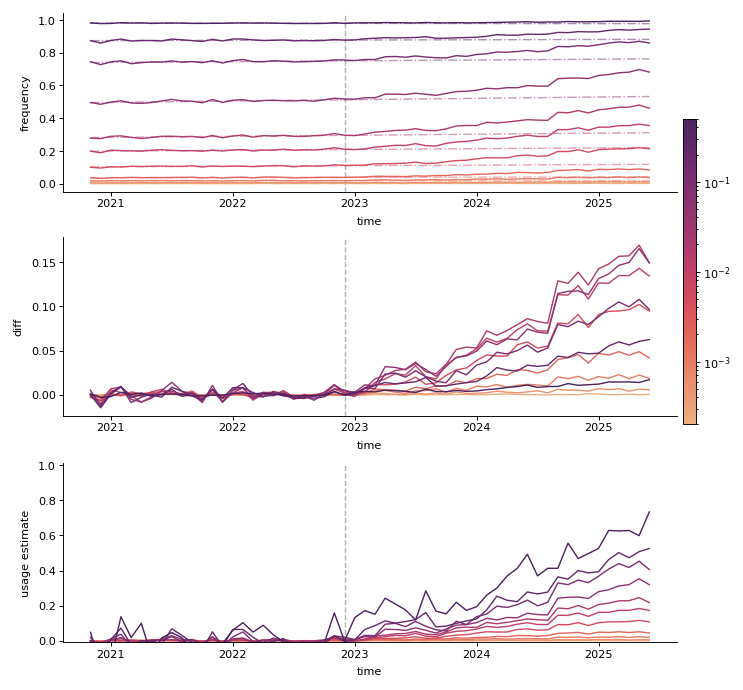

In [16]:
fig, axs = plt.subplots(nrows=3, ncols=1, figsize=(5, 5), layout="constrained")

hue_norm = LogNorm()
palette = "flare"
data = freqs_dfs_filtered["results"]
for i, var in enumerate(["frequency", "diff", "usage estimate"]):
    ax = axs.flatten()[i]

    ax.axvline(x=2022 + (11 / 12), linestyle="--", color="black", alpha=0.3)
    sns.lineplot(
        data=data,
        x="time",
        y=var,
        hue="cutoff",
        hue_norm=hue_norm,
        palette=palette,
        ax=ax,
        legend=False,
    )

    if var == "frequency":
        sns.lineplot(
            data=data,
            x="time",
            y="projection",
            hue="cutoff",
            hue_norm=LogNorm(),
            palette=palette,
            ax=ax,
            alpha=0.5,
            linestyle="-.",
            legend=False,
        )

    if var == "usage estimate":
        ax.set_ylim(-0.01, 1.01)

    if var == "diff":
        sm = plt.cm.ScalarMappable(cmap=palette, norm=hue_norm)
        cax = fig.add_axes(
            [
                ax.get_position().x1 + 0.1,
                ax.get_position().y0,
                0.02,
                ax.get_position().height * 2,
            ]
        )
        ax.figure.colorbar(sm, cax=cax)

In [17]:
freqs_df_agg = {}
for sec in secs:
    df = freqs_dfs[sec].copy()
    df["time"] = list(map(math.floor, df["time"]))
    df = df.groupby(["time", "cutoff"]).mean().reset_index()
    freqs_df_agg[sec] = df

In [18]:
freqs_df_filtered_agg = {}
for sec in secs:
    df = freqs_dfs_filtered[sec].copy()
    df["time"] = list(map(math.floor, df["time"]))
    df = df.groupby(["time", "cutoff"]).mean().reset_index()
    freqs_df_filtered_agg[sec] = df

In [19]:
freqs_df_agg["introduction"][freqs_df_agg["introduction"]["time"] == 2024]

,time,cutoff,frequency,projection,diff,usage estimate,se
48,2024,0.0002,0.000099,0.000070,0.000029,0.000029,0.000037
49,2024,0.0005,0.004135,0.002749,0.001386,0.001390,0.000239
50,2024,0.0010,0.023839,0.012669,0.011171,0.011314,0.000550
51,2024,0.0020,0.071897,0.038471,0.033426,0.034766,0.000954
52,2024,0.0050,0.186680,0.110071,0.076609,0.086099,0.001566
53,2024,0.0100,0.355640,0.244015,0.111625,0.147743,0.002297
54,2024,0.0200,0.545353,0.410000,0.135354,0.229679,0.003055
55,2024,0.0500,0.799055,0.696899,0.102156,0.337698,0.004780
56,2024,0.1000,0.939825,0.908366,0.031458,0.344785,0.009537
57,2024,0.2000,0.983377,0.973711,0.009666,0.369485,0.017815


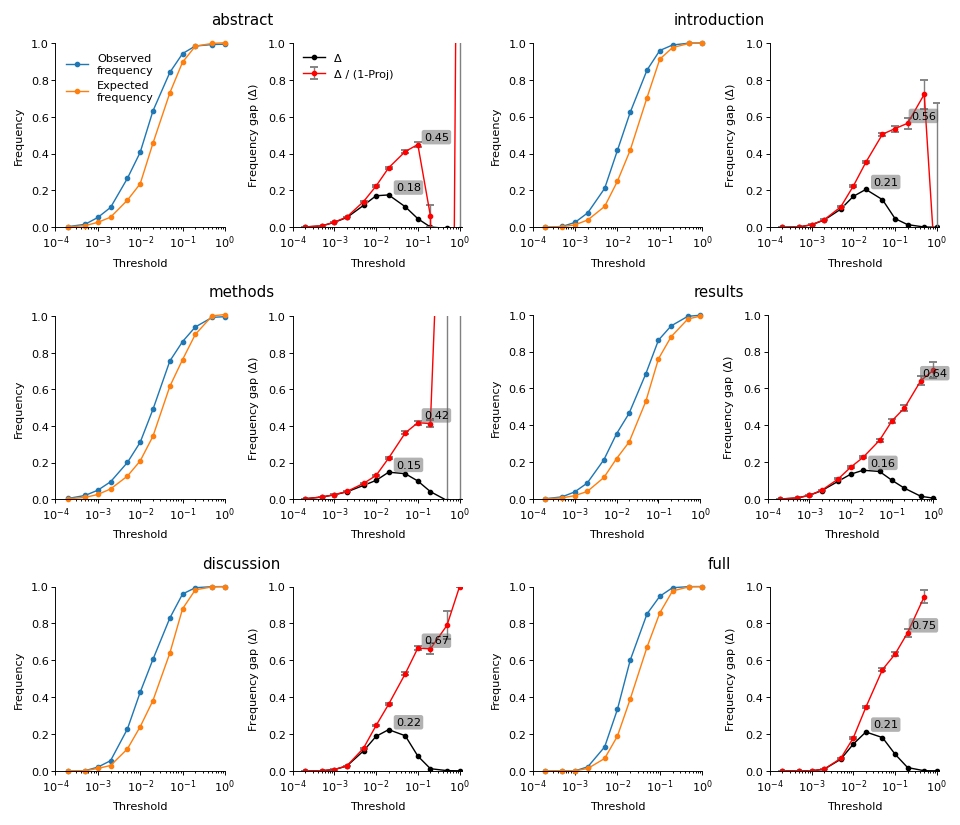

In [20]:
# ensure correct order
sections = ["abstract", "introduction", "methods", "results", "discussion", "full"]

fig = plt.figure(figsize=(7, 6), layout="constrained")
subfigs = fig.subfigures(3, 2)  # outer grid

for subfig, sec in zip(subfigs.flat, sections):
    f = freqs_df_agg[sec][freqs_df_agg[sec]["time"] == 2025]
    f_filt = freqs_df_filtered_agg[sec][freqs_df_filtered_agg[sec]["time"] == 2025]

    axs = subfig.subplots(1, 2)  # inner grid

    subfig.suptitle(sec)

    # frequency plot
    axs[0].plot(
        f["cutoff"], f["frequency"], ".-", clip_on=False, label="Observed\nfrequency"
    )
    axs[0].plot(
        f["cutoff"], f["projection"], ".-", clip_on=False, label="Expected\nfrequency"
    )
    axs[0].set_xscale("log")
    axs[0].set_xlim([1e-4, 1])
    axs[0].set_ylim([0, 1])
    axs[0].set_ylabel("Frequency")
    axs[0].set_xlabel("Threshold")
    if sec == "abstract":
        axs[0].legend()

    # usage estimate plot
    axs[1].plot(f["cutoff"], f["diff"], "k.-", label="Δ")
    # axs[1].plot(f_filt["cutoff"], f_filt["usage estimate"], "r.-", label="Δ / (1-Proj)")
    axs[1].errorbar(
        f["cutoff"],
        f["usage estimate"],
        yerr=list(map(lambda x: x * 2, f["se"])),  # ±2 standard errors
        fmt="r.-",
        ecolor="grey",
        capsize=2,
        label="Δ / (1-Proj)",
    )

    i = int(np.argmax(f_filt["usage estimate"]))
    axs[1].text(
        list(f_filt["cutoff"])[i] + 0.04,
        list(f_filt["usage estimate"])[i] + 0.04,
        f"{list(f["usage estimate"])[i]:.2f}",
        va="center",
        bbox=dict(
            edgecolor="none", facecolor="#666666", alpha=0.5, boxstyle="round,pad=.2"
        ),
    )
    i = int(np.argmax(f["diff"]))
    axs[1].text(
        list(f["cutoff"])[i] + 0.01,
        list(f["diff"])[i] + 0.04,
        f"{list(f["diff"])[i]:.2f}",
        va="center",
        bbox=dict(
            edgecolor="none", facecolor="#666666", alpha=0.5, boxstyle="round,pad=.2"
        ),
    )
    axs[1].set_xscale("log")
    axs[1].set_xlim([1e-4, 1.15])
    axs[1].set_ylim([0, 1])
    axs[1].set_ylabel(r"Frequency gap ($\Delta$)")
    axs[1].set_xlabel("Threshold")
    if sec == "abstract":
        axs[1].legend()

plt.savefig(
    os.path.join(
        "../results/plots", VERSION, f"lower_bound_non_lemmatized_{vocab_version}.png"
    ),
    dpi=300,
)

In [21]:
np.argmax(f["usage estimate"])

np.int64(10)

In [22]:
f["usage estimate"]

60    0.000050
61    0.000050
62    0.000050
63    0.009040
64    0.067370
65    0.178876
66    0.345169
67    0.549502
68    0.633169
69    0.749767
70    0.945402
71         NaN
Name: usage estimate, dtype: float64

In [23]:
excess_words_cutoff["introduction"][0.05]

array(['accentuates', 'achieving', 'acknowledges', 'acknowledging',
       'addresses', 'addressing', 'adept', 'adhered', 'adhering',
       'advancement', 'advancements', 'advancing', 'advocates',
       'advocating', 'affirming', 'afflicted', 'aiding', 'akin', 'align',
       'aligning', 'aligns', 'alongside', 'amidst', 'assessments',
       'attains', 'augmenting', 'avenue', 'avenues', 'bolster',
       'bolstered', 'bolstering', 'broader', 'burgeoning', 'capabilities',
       'capitalizing', 'categorized', 'categorizes', 'categorizing',
       'combating', 'commendable', 'compelling', 'complicates',
       'complicating', 'comprehending', 'comprising', 'consolidates',
       'conversely', 'correlating', 'crafted', 'crafting', 'culminating',
       'customizing', 'delineates', 'delve', 'delved', 'delves',
       'delving', 'demonstrates', 'demonstrating', 'dependability',
       'dependable', 'detailing', 'detrimentally', 'diminishes',
       'diminishing', 'discern', 'discerned', '